In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score,recall_score,f1_score

In [6]:
dataset2 = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/ensemble.csv')

In [7]:
dataset2.head()

,X1,X2,y
0,-0.665227,-0.161289,0
1,1.747817,-0.054035,0
2,0.792945,0.687195,1
3,0.533777,-1.436711,0
4,0.841554,0.912889,1


In [8]:
dataset2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1000 non-null   float64
 1   X2      1000 non-null   float64
 2   y       1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [11]:
X = dataset2[['X1','X2']]

In [13]:
y = dataset2['y']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Define the base models 

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [53]:
log_clf = LogisticRegression()
dt_clf = DecisionTreeClassifier()
knn_clf = KNeighborsClassifier()

In [54]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_clf),
        ('dt', dt_clf),
        ('knn', knn_clf)
    ],
    voting='hard'
)

In [55]:
voting_clf.fit(X_train, y_train)
y_pred = voting_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [56]:
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 80.40%


In [57]:
print(f'Recall: {recall * 100:.2f}%')

Recall: 57.14%


In [58]:
print(f'F1 Score: {f1 * 100:.2f}%')

F1 Score: 62.02%


In [59]:
models = {
    'VotingClassifier Ensemble': VotingClassifier(estimators=[
        ('lr', LogisticRegression()),
        ('dt', DecisionTreeClassifier()),
        ('knn', KNeighborsClassifier())
    ], voting='hard'),

    'DecisionTreeClassifier(max_depth=3)': DecisionTreeClassifier(max_depth=3),
    'KNeighborsClassifier(n_neighbors=4)': KNeighborsClassifier(n_neighbors=4),
    'KNeighborsClassifier(n_neighbors=5)': KNeighborsClassifier(n_neighbors=5),
    'KNeighborsClassifier(n_neighbors=3)': KNeighborsClassifier(n_neighbors=3),
    'DecisionTreeClassifier(max_depth=4)': DecisionTreeClassifier(max_depth=4)
}

In [60]:
from sklearn.metrics import precision_score

In [61]:
# Evaluate precision scores
precision_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = precision_score(y_test, y_pred, zero_division=0)
    precision_scores[name] = score

# Display results
for name, score in precision_scores.items():
    print(f"{name}: Precision Score = {score:.2f}")

# Identify best model
best_model = max(precision_scores, key=precision_scores.get)
print(f"\n🏆 Best Precision Score: {best_model} with {precision_scores[best_model]:.2f}")

VotingClassifier Ensemble: Precision Score = 0.69
DecisionTreeClassifier(max_depth=3): Precision Score = 0.79
KNeighborsClassifier(n_neighbors=4): Precision Score = 0.69
KNeighborsClassifier(n_neighbors=5): Precision Score = 0.66
KNeighborsClassifier(n_neighbors=3): Precision Score = 0.65
DecisionTreeClassifier(max_depth=4): Precision Score = 0.78

🏆 Best Precision Score: DecisionTreeClassifier(max_depth=3) with 0.79


In [62]:
recall_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = recall_score(y_test, y_pred, zero_division=0)
    recall_scores[name] = score

# Display results
for name, score in recall_scores.items():
    print(f"{name}: Recall Score = {score:.2f}")

# Identify best model
best_model = max(recall_scores, key=recall_scores.get)
print(f"\n🏆 Best Recall Score: {best_model} with {recall_scores[best_model]:.2f}")

VotingClassifier Ensemble: Recall Score = 0.57
DecisionTreeClassifier(max_depth=3): Recall Score = 0.44
KNeighborsClassifier(n_neighbors=4): Recall Score = 0.54
KNeighborsClassifier(n_neighbors=5): Recall Score = 0.63
KNeighborsClassifier(n_neighbors=3): Recall Score = 0.66
DecisionTreeClassifier(max_depth=4): Recall Score = 0.44

🏆 Best Recall Score: KNeighborsClassifier(n_neighbors=3) with 0.66


In [63]:
dataset3 = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/ensemble2.csv')

In [64]:
dataset3.head()

,X1,X2,X3,X4,X5,y
0,1.555730,0.628147,-0.567278,-2.548786,-1.575909,2
1,-1.760054,-0.417340,0.353626,2.383121,0.172636,0
2,-0.329064,-0.461760,-1.183120,1.436410,-1.228790,0
3,-1.801581,0.075704,1.623614,1.218431,1.051731,0
4,0.543973,-0.595228,-1.202407,0.872089,0.185406,0


In [65]:
dataset3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1000 non-null   float64
 1   X2      1000 non-null   float64
 2   X3      1000 non-null   float64
 3   X4      1000 non-null   float64
 4   X5      1000 non-null   float64
 5   y       1000 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 47.0 KB


In [66]:
dataset3.describe()

,X1,X2,X3,X4,X5,y
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.267090,-0.174022,-0.128434,0.610613,0.031579,0.409000
std,1.282626,0.509495,1.328040,1.236867,1.209951,0.672437
min,-4.693368,-1.719279,-4.022879,-3.224026,-3.664033,0.000000
25%,-0.963761,-0.492231,-1.124822,-0.136607,-0.983002,0.000000
50%,-0.209032,-0.178900,-0.479385,0.680229,0.246709,0.000000
75%,0.464777,0.119807,0.903428,1.498429,1.019397,1.000000
max,4.607026,1.697637,4.100911,4.292105,2.860860,2.000000


Define base regressors 

In [67]:
from sklearn.neighbors import KNeighborsRegressor

In [68]:
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
knn = KNeighborsRegressor()

In [69]:
from sklearn.ensemble import VotingRegressor

In [70]:
voting_reg = VotingRegressor(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('knn', knn)
    ]   
)

In [71]:
voting_reg.fit(X_train, y_train)
y_pred = voting_reg.predict(X_test)

In [72]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')

RMSE: 0.40


In [73]:
# Define models
models = {
    'KNeighborsRegressor(n_neighbors=5)': KNeighborsRegressor(n_neighbors=5),
    'DecisionTreeRegressor(max_depth=5)': DecisionTreeRegressor(max_depth=5, random_state=42),
    'LinearRegression': LinearRegression(),
    'VotingRegressor Ensemble': VotingRegressor(estimators=[
        ('lr', LinearRegression()),
        ('dt', DecisionTreeRegressor(max_depth=5, random_state=42)),
        ('knn', KNeighborsRegressor(n_neighbors=5))
    ])
}

# Evaluate RMSE scores
rmse_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_scores[name] = rmse

# Display results
for name, score in rmse_scores.items():
    print(f"{name}: RMSE = {score:.4f}")

# Identify worst performer
worst_model = max(rmse_scores, key=rmse_scores.get)
print(f"\n📉 Highest RMSE: {worst_model} with {rmse_scores[worst_model]:.4f}")

KNeighborsRegressor(n_neighbors=5): RMSE = 0.3984
DecisionTreeRegressor(max_depth=5): RMSE = 0.3927
LinearRegression: RMSE = 0.3851
VotingRegressor Ensemble: RMSE = 0.3740

📉 Highest RMSE: KNeighborsRegressor(n_neighbors=5) with 0.3984


In [74]:
dataset3 = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/ensemble3.csv')

In [75]:
dataset3.head()

,X1,X2,X3,X4,X5,y
0,1.555730,0.628147,-0.567278,-2.548786,-1.575909,2
1,-1.760054,-0.417340,0.353626,2.383121,0.172636,0
2,-0.329064,-0.461760,-1.183120,1.436410,-1.228790,0
3,-1.801581,0.075704,1.623614,1.218431,1.051731,0
4,0.543973,-0.595228,-1.202407,0.872089,0.185406,0


In [76]:
dataset3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1000 non-null   float64
 1   X2      1000 non-null   float64
 2   X3      1000 non-null   float64
 3   X4      1000 non-null   float64
 4   X5      1000 non-null   float64
 5   y       1000 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 47.0 KB


In [77]:
X = dataset3[['X1','X2','X3','X4',
              'X5']]

In [78]:
y = dataset3['y']

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [80]:
from sklearn.ensemble import RandomForestClassifier

In [81]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

In [82]:
rf_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [83]:
y_pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 89.20%


In [ ]:
from sklearn.ensemble import 

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [87]:
y_pred = rf_clf.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'F1 Score: {f1 * 100:.2f}%')

F1 Score: 90.97%


In [88]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:",cm)

Confusion Matrix: [[206   2   5]
 [  7  42   4]
 [  1   8  25]]


In [89]:
tp_label_0_0 = cm[0, 0]
print("True Positives for label 0:", tp_label_0_0)

True Positives for label 0: 206


Boosting in Python

In [1]:
from sklearn.model_selection import train_test_split

In [2]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [3]:
### Generate Synthetic Data
X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [5]:
### Single Weak learner 
stump = DecisionTreeClassifier(max_depth=1, random_state=42)

In [6]:
### Full tree, for comparison
tree = DecisionTreeClassifier(random_state=42) ### no limit on max depth 

In [8]:
from sklearn.ensemble import AdaBoostClassifier

In [11]:
### Adaboost ensemble of 50 stumps 
ada = AdaBoostClassifier(estimator = DecisionTreeClassifier(max_depth=1),
                         n_estimators=50,
                            learning_rate=1.0, 
                            random_state=0)

In [12]:
### Fit model to training data 
stump.fit(X_train, y_train)
tree.fit(X_train, y_train)
ada.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   random_state=0)

In [19]:
### Genearate predictions on test data
stump_pred = stump.predict(X_test)
tree_pred = tree.predict(X_test)
ada_pred = ada.predict(X_test)

In [17]:
print(f'Stump Accuracy: {accuracy_score(y_test, stump_pred) * 100:.2f}%')
print(f'Tree Accuracy: {accuracy_score(y_test, tree_pred) * 100:.2f}%')
print(f'AdaBoost Accuracy: {accuracy_score(y_test, ada_pred) * 100:.2f}%')

Stump Accuracy: 82.33%
Tree Accuracy: 93.00%
AdaBoost Accuracy: 95.00%


In [21]:
def compute_metrics (name,y_test,y_preds):
    accuracy = accuracy_score(y_test, y_preds) * 100
    precision = precision_score(y_test, y_preds) * 100
    recall = recall_score(y_test, y_preds) * 100
    f1 = f1_score(y_test, y_preds) * 100
    print(f'{name} - Accuracy: {accuracy:.2f}%, Precision: {precision:.2f}%, Recall: {recall:.2f}%, F1 Score: {f1:.2f}%')
    return

In [22]:
compute_metrics('Stump', y_test, stump_pred)

Stump - Accuracy: 82.33%, Precision: 83.70%, Recall: 78.47%, F1 Score: 81.00%


In [23]:
compute_metrics('Full Decision Tree', y_test, tree_pred)

Full Decision Tree - Accuracy: 93.00%, Precision: 94.89%, Recall: 90.28%, F1 Score: 92.53%


In [24]:
compute_metrics('Adaboost', y_test, ada_pred)

Adaboost - Accuracy: 95.00%, Precision: 93.88%, Recall: 95.83%, F1 Score: 94.85%


In [28]:
cf_dataset1 = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/clf-dataset01.csv')

In [30]:
cf_dataset1.head()

,X1,X2,y
0,0.360289,0.907079,0
1,0.487743,-0.293079,1
2,0.802645,0.452520,0
3,1.021270,-0.503749,1
4,1.134119,0.011527,0


In [32]:
X = cf_dataset1[['X1','X2']]
y = cf_dataset1['y']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42,
                                                    stratify=y)

In [35]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [36]:
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 96.00%


In [37]:
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'F1 Score: {f1 * 100:.2f}%')

F1 Score: 96.00%


In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [39]:
from sklearn.tree import DecisionTreeClassifier

In [40]:
gb = GradientBoostingClassifier(n_estimators=100,
                                learning_rate=0.1,
                                max_depth=3,
                                random_state=42)

In [41]:
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [42]:
### Extract the first stump
first_stump = gb.estimators_[0, 0]

In [43]:
raw_pred = first_stump.predict(X_test.values)

In [45]:
y_pred = (raw_pred > 0).astype(int)

In [49]:
weighted_precision = precision_score(y_test, y_pred, average='weighted')


In [50]:
print(f"Weighted Precision of the first stump: {weighted_precision:.2f}")

Weighted Precision of the first stump: 0.90


In [51]:
weighted_recall = recall_score(y_test, y_pred, average='weighted')
print(f"Weighted Recall of the first stump: {weighted_recall:.2f}")

Weighted Recall of the first stump: 0.90


In [52]:
clf_dataset2 = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/clf-dataset08.csv')

In [53]:
clf_dataset2.head()

,X1,X2,X3,X4,X5,X6,y
0,-0.318514,-0.182128,0.981894,-1.607560,1.680242,1.540194,1
1,1.028638,0.233708,1.923055,0.593557,1.949668,0.695116,1
2,-0.573774,-1.082063,-0.719297,-0.650003,-0.766568,0.309679,0
3,0.258538,-0.729560,-0.968332,-0.447322,-1.794882,-1.149108,0
4,1.238943,0.296422,1.942978,0.659246,1.805563,0.425472,1


In [54]:
X = clf_dataset2.iloc[:,:-1]
y = clf_dataset2.iloc[:,-1]

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42,
                                                    stratify=y)

In [57]:
from sklearn.neighbors import KNeighborsClassifier

In [62]:
from sklearn.svm import SVC

In [63]:
from sklearn.linear_model import LogisticRegression

In [64]:
estimators = [
    ('dt', DecisionTreeClassifier(max_depth=3, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('svc', SVC(probability=True, random_state=42)),
    ('lr', LogisticRegression())
]

In [65]:
meta = LogisticRegression(random_state=42)

In [67]:
from sklearn.ensemble import StackingClassifier

In [68]:
stack = StackingClassifier(estimators=estimators,
                            final_estimator=meta,
                            cv=5)

In [71]:
stack.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('dt',
                                DecisionTreeClassifier(max_depth=3,
                                                       random_state=42)),
                               ('knn', KNeighborsClassifier()),
                               ('svc', SVC(probability=True, random_state=42)),
                               ('lr', LogisticRegression())],
                   final_estimator=LogisticRegression(random_state=42))

In [73]:
y_pred = stack.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 96.67%


In [74]:
meta_learner = LogisticRegression(random_state=42)

In [78]:
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_learner,
    cv=5,                    # 5-fold cross-validation for meta-features
    n_jobs=-1,               # Use all CPU cores
    passthrough=False        # Don't pass original features to meta-learner
)

In [79]:
stacking_clf.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('dt',
                                DecisionTreeClassifier(max_depth=3,
                                                       random_state=42)),
                               ('knn', KNeighborsClassifier()),
                               ('svc', SVC(probability=True, random_state=42)),
                               ('lr', LogisticRegression())],
                   final_estimator=LogisticRegression(random_state=42),
                   n_jobs=-1)

In [80]:
y_pred = stacking_clf.predict(X_test)

In [82]:
weighted_f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Weighted F1 Score of first stump: {weighted_f1 * 100:.2f}%')

Weighted F1 Score of first stump: 96.64%


In [1]:
import random

In [11]:
random.seed(500)

In [12]:
###Simulate 1000 coin flips 
coin_tosses = [random.choice(['Heads', 'Tails']) for _ in range(1000)]
### Printing first 10 coin tosses
print(coin_tosses[:10])

['Tails', 'Tails', 'Tails', 'Tails', 'Heads', 'Heads', 'Tails', 'Heads', 'Heads', 'Heads']


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [14]:
### Convert to dataframes 
df_coin = pd.DataFrame(coin_tosses, columns=['Outcome'])

Number of Heads: 461, Number of Tails: 539


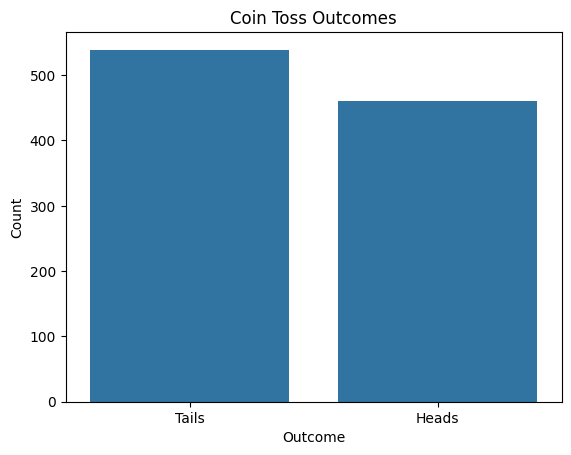

In [15]:
num_heads = df_coin['Outcome'].value_counts()['Heads']
num_tails = df_coin['Outcome'].value_counts()['Tails']
print(f'Number of Heads: {num_heads}, Number of Tails: {num_tails}')

###Plot coint tosses
sns.countplot(x='Outcome', data=df_coin)
plt.title('Coin Toss Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = [
    {"id": 1, "message": "free offer win", "label": "spam"},
    {"id": 2, "message": "win free", "label": "spam"},
    {"id": 3, "message": "offer free", "label": "spam"},
    {"id": 4, "message": "free win", "label": "spam"},
    {"id": 5, "message": "hello lunch", "label": "ham"},
    {"id": 6, "message": "lunch hello", "label": "ham"},
    {"id": 7, "message": "hello", "label": "ham"},
    {"id": 8, "message": "hello lunch", "label": "ham"},
]

In [4]:
totalmessage = len(data)
print(f'Total Messages: {totalmessage}')

Total Messages: 8


In [5]:
spam_messages = sum(1 for item in data if item['label'] == 'spam')
ham_messages = totalmessage - spam_messages

In [6]:
P_spam = spam_messages / totalmessage
P_ham = ham_messages / totalmessage
print(f'P(spam): {P_spam:.2f}, P(ham): {P_ham:.2f}')
print(f'P(spam): {P_spam:.2f}, P(ham): {P_ham:.2f}')

P(spam): 0.50, P(ham): 0.50
P(spam): 0.50, P(ham): 0.50


In [ ]:

# Word counts per class (from training set)
spam_counts = {"free": 2, "win": 1, "hello": 0}
ham_counts = {"free": 0, "win": 0, "hello": 2}
vocab = ["free", "win", "hello"]
V = len(vocab)